Why explainability matters:? 
In production, especially for credit/finance:

Regulators may require explanations for decisions
"Why was this person denied credit?" needs an answer
Helps detect model bias or unexpected behavior

In [2]:
%load_ext dotenv
%dotenv 
%run update_path.py

import os
import pandas as pd
import numpy as np
import pickle
ft_path = os.getenv("CREDIT_DATA")
df_raw = pd.read_csv(ft_path)

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [3]:
from credit.data import load_data

X, Y = load_data()

2026-06-13 13:26:21,364, data.py, 50, INFO, Loading credit data from ../../05_src/data/credit/cs-training.csv


# Loading Model Artifacts

Previously, we built a procedure for hyperparameter tuning. The process produces parametrized models that use the optimal parameters based on Grid Search or Hyperopt. The models are saved in the object store. We can access these objects via MLflow's API using the URI: `models:/<model name>/<model version>`

Alternatively, the model could have been stored using the standard pickle format. We can load a model using `pickle.load()` within  a context manager that handles the file (a `with(open(f, 'rb'))...` statement). The context manager will help close files in case of unexpected termination.

In [ ]:
# import mlflow.sklearn
# mlflow.set_tracking_uri('http://localhost:5001')
# model_name = 'CreditLogisticModel'
# model_version = '6'
# model_uri = f'models:/{model_name}/{model_version}'
# pipe = mlflow.sklearn.load_model(model_uri)
# pipe

In [4]:
#yay let's open the logistic regression model we just ran on 05 
with open('./models/credit_logistic_grid_search.pkl', 'rb') as f:
    pipe = pickle.load(f)

In this case, we loaded a logistic regression model. The model, however, could have been from another family of models (Random Forest, Neural Net, etc.)

Below, we will explore some model-agnostic explainability methods.

# Partial Dependence Plots

+ [Partial Dependence Plots (PDP)](https://scikit-learn.org/stable/modules/partial_dependence.html) show the relationship between the target response and the input feature. 
+ They can be constructed for one or two inputs at a time.

In [5]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Why do we fit again?
#When you saved the model with pickle and loaded it back:
#The loaded pipe contains the fitted model — but PartialDependenceDisplay needs access to both:
##The fitted model ✅ (already have this)
##The training data to compute partial dependence values

pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_simple', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Single-Feature PDP

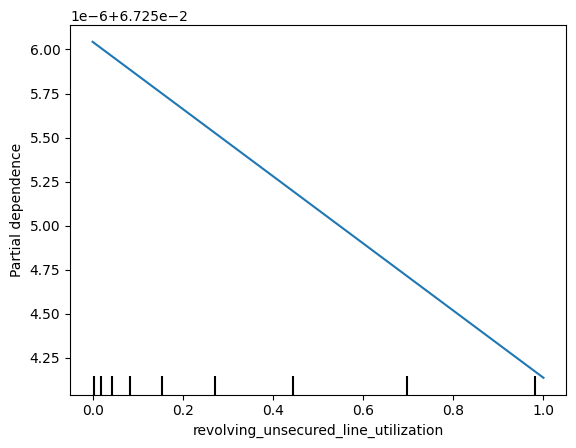

In [6]:
#This generates a Partial Dependence Plot for one feature -->  revolving_unsecured_line_utilization
PartialDependenceDisplay.from_estimator(pipe, X_train, 
                                        features = ['revolving_unsecured_line_utilization'])


What the plot shows:

The x-axis is the range of revolving_unsecured_line_utilization values. The y-axis is the predicted probability of delinquency.

It answers: "if we change ONLY revolving_unsecured_line_utilization and keep everything else constant, how does delinquency risk change?"


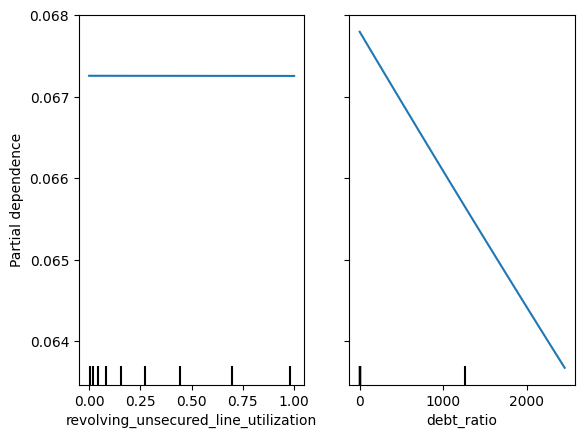

In [7]:
#one feature still, side by side 
PartialDependenceDisplay.from_estimator(pipe, X_train, 
                                        features = ['revolving_unsecured_line_utilization', 'debt_ratio'])

Interpretation: No matter how high or low credit utilization is, the predicted delinquency probability barely changes


## Two-Feature PDP

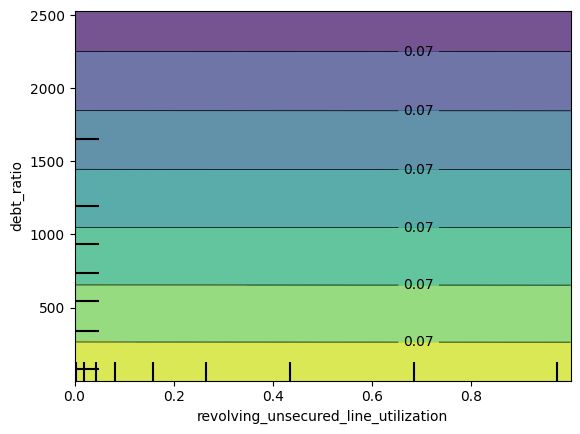

In [8]:
#let's to two features!
PartialDependenceDisplay.from_estimator(pipe, X_train.sample(10000, random_state=42), 
                                        features = [('revolving_unsecured_line_utilization', 'debt_ratio')],
                                        grid_resolution=50)

Instead of using all of X_train, it samples 10,000 rows. Why?
A two-feature PDP is computationally expensive — it creates a grid of value combinations for both features and makes predictions for each point. Using the full training set would take too long. 10,000 rows is a representative sample that's fast enough.

now we are also getting an interaction plot!

The output is a heatmap where:

x-axis = revolving_unsecured_line_utilization
y-axis = debt_ratio
Color = predicted delinquency probability

## Partial Dependence Values

You may require the underlying data of the plots above. To obtain it, use the function [`partial_dependence()`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.partial_dependence.html#sklearn.inspection.partial_dependence).

In [ ]:
# this is crashing 
#This is the raw data version of the plots you just saw:
from sklearn.inspection import partial_dependence

partial_dependence(pipe, X_train, features = ['revolving_unsecured_line_utilization', 'debt_ratio'])    

KeyboardInterrupt: 

## Permutation Feature Importance

+ Permutation feature importance measures the contribution of each feature to a fitted model's performance.
+ Randomly shuffles the values of a single feature and observes the resulting degradation of the model's score. If shuffling a feature greatly degrades performance, then we say the feature is important.
+ Since shuffling introduces randomness, it is advisable (though computationally costly) to perform several repetitions.

[Scikit's Documentation](https://scikit-learn.org/stable/modules/permutation_importance.html) makes this warning:

> **Warning**: Features that are deemed of **low importance for a bad model** (low cross-validation score) could be **very important for a good model**. Therefore it is always important to evaluate the predictive power of a model using a held-out set (or better with cross-validation) prior to computing importances. Permutation importance does not reflect to the intrinsic predictive value of a feature by itself but how important this feature is for a particular model. 

In [9]:
from sklearn.inspection import permutation_importance

pi_res = permutation_importance(
    pipe, X_test, y_test, 
    n_repeats=30, 
    scoring = "neg_log_loss")

The concept — how permutation importance works:
For each feature, one at a time:

Shuffle that feature's values randomly (breaking its relationship with the target)
Measure how much model performance drops
Repeat n_repeats times to get a stable estimate

The function returns a dictionary with the following entries:

+ `importances_mean`: mean of feature importance.
+ `importances_std`: standard deviation of feature importance over n_repeats.
+ `importances`: raw permutation importance scores (one feature per row, one reshuffle per column).

In [10]:
#The raw importance score --> convert into dataframe(10, 30) — 10 rows (features), 30 columns (repeats)
#.T — transposes it, flipping rows and columns to (30, 10) — 30 rows (repeats), 10 columns (features)
importances_dt = pd.DataFrame(pi_res.importances).T
#Assigns the actual feature names as column headers:
importances_dt.columns = X_test.columns

/var/folders/13/p1m2db392nd5bmkffwxs15zm0000gn/T/ipykernel_6405/670374971.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(importances_dt, vert = False,  labels = importances_dt.columns)


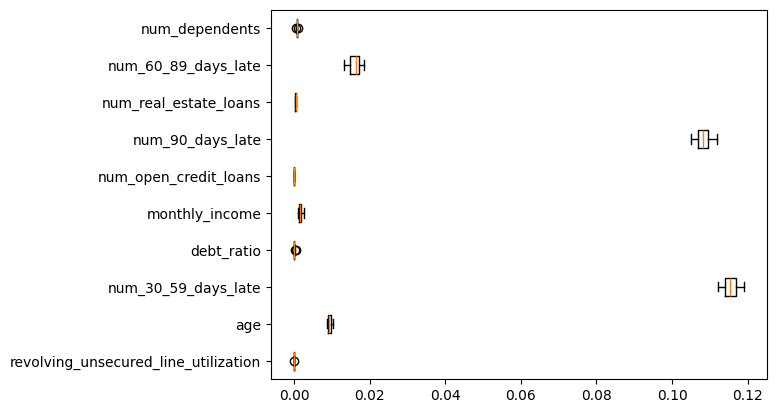

In [11]:
import matplotlib.pyplot as plt

#This creates a boxplot of feature importances — showing the distribution of importance scores across all 30 repeats:
bp = plt.boxplot(importances_dt, vert = False,  labels = importances_dt.columns)

plt.boxplot(importances_dt)
#Draws one box per column (feature) in importances_dt — so 10 boxes total, one per feature.

vert=False
#Makes the boxes horizontal instead of vertical — easier to read feature names on the y-axis.

labels=importances_dt.columns
#Labels each box with the feature name.

In [12]:
#clean summary table of feature importances.
#Creates a Series of average importance scores across 30 repeats, one per feature:
###Sorts by mean importance — most important feature at the top.
pd.concat(
    [
        pd.Series(pi_res.importances_mean, index = X_test.columns, name = 'Mean Importance'),
        pd.Series(pi_res.importances_std, index = X_test.columns, name = "Std Importance")
    ], 
    axis = 1).sort_values("Mean Importance", ascending  = False)

,Mean Importance,Std Importance
num_30_59_days_late,0.115513,0.001842
num_90_days_late,0.108435,0.001767
num_60_89_days_late,0.015964,0.001505
age,0.009403,0.000441
monthly_income,0.001655,0.000457
num_dependents,0.000793,0.000115
num_real_estate_loans,0.000404,0.000088
num_open_credit_loans,0.000065,0.000037
debt_ratio,0.000064,0.000121
revolving_unsecured_line_utilization,0.000004,0.000011


## SHAP Values


+ SHAP is an advanced approach for providing explanations for model results. 
+ One library that implements this procedure is [SHAP](https://shap.readthedocs.io/en/latest/).


### Explainers

+ SHAP values can be calculated for any model, however, the procedure can be computationally expensive.
+ For certain models, some specific functions exist to speed the calculations: they are contained in the [`shap.explainers`](https://shap.readthedocs.io/en/latest/api.html#explainers) module. A few notable functions are:

    - [`shap.Explainer()`](https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html#shap.Explainer): the primary explainer interface and chooses the explanation algorithm for you.
    - [`shap.TreeExplainer()`](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html#shap.TreeExplainer): implements Tree Shap, a procedure optimized for tree-based ensemble methods (Random Forest, XGBoost, etc.)
    - [`shap.LinearExplainer()`](https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html#shap.LinearExplainer): computes SHAP Values for linear methods.

### Obtaining explanations from shap

+ Shap can obtain local and global explanations. The model produces additive explanations, therefore, obtaining global explanations is equivalent to obtaining individual explanations for all samples.
+ Shap can obtain explanations for testing and training samples.
+ Local explanations are obtained as shap_values, which reflect the contribution of each feature to the prediction made for each sample.

### Using the shap package

+ SHAP works on classifiers, but our pipelines contain preprocessing and classification steps. 
+ We can access each individual step through the `.named_steps` attribute.
+ Notice that we apply the transformation (`ColumnTransformer`) step to obtain transformed data and store the results in `data_transform`.
+ Feature names are obtained from the preprocessor's `.get_feature_names_out()` which exposes the names of the features after they have been transformed by the `ColumnTransformer`.
+ The explainer object is then used to provide all explanations in `data_transform`.

In [ ]:
import shap
#Extracts the preprocessed version of X_test — applies imputation and scaling but stops before the classifier. 
# This is the data SHAP will work with.
data_transform = pipe.named_steps['preprocess'].transform(X_test)

explainer = shap.explainers.Linear(
    # just the LogisticRegression object
    pipe.named_steps['clf'], 
    #the transformed background dataset SHAP uses to compute expected values
    data_transform,
    #gets column names after transformation:
    feature_names = pipe.named_steps['preprocess'].get_feature_names_out())

#Computes SHAP values for every row — how much each feature pushed each prediction up or down from the baseline.
shap_values = explainer(data_transform)

### Waterfall Plots

From [SHAP's documentation](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html) (emphasis added):


> Waterfall plots are designed to display explanations for **individual predictions**, so they expect a single row of an Explanation object as input. The bottom of a waterfall plot starts as the expected value of the model output, and then each row shows how the positive (red) or negative (blue) contribution of each feature moves the value from the expected model output over the background dataset to the model output for this prediction.

+ The waterfall plot below shows the contribution of each feature to an individual prediction. 
+ Only the most important features are shown, while the least important features are grouped together at the bottom of the chart (e.g., "4 other features").



In [ ]:
shap.plots.waterfall(shap_values[1])

### Beeswarm plot

+ Beeswarm plots display the contributions of each feature to all cases in the sample. The feature values are color-coded when available. 
+ Beeswarm plots summarize the behaviour of the model across all items in the sample.


In [ ]:
shap.plots.beeswarm(shap_values)